In [2]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

from src.io import load_data
from src.feature import annotate_labels, our_feature
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar,
    nankurtosis,
)
from src.learning import random_fit_and_eval, set_seed


## Load Data

In [3]:
data_folder = '/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/raw'
data = load_data(data_folder)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells: 100%|██████████| 151/151 [58:23<00:00, 23.20s/it] 


In [4]:
xps_df = pd.read_csv('/data/Blob_EastUS/xiaofan/battery/all_temp_new/data/xps_data.csv', index_col=0)
y_fixed = [fixed_labels[x] for x in xps_df.date_tag]
y_rel = [relative_labels[x] for x in xps_df.date_tag]
xps_df = xps_df.assign(**{
    'CO': xps_df['C1s'] + xps_df['O1s'],
    'PF': xps_df['P2p'] + xps_df['F1s'],
    'CO/(CO+PF)': (xps_df['C1s'] + xps_df['O1s']) / (
        xps_df['C1s'] + xps_df['O1s'] + xps_df['P2p'] + xps_df['F1s']
    ),
    'life_fixed': y_fixed,
    'life_relative': y_rel,
    'temperature': xps_df.temp1
})
xps_target_columns = [
    'Li1s', 'C1s', 'O1s', 'F1s',
    'P2p', 'Ni3p1', 'Co3p1', 'Mn3p',
    'CO', 'PF', 'CO/(CO+PF)'
]
xps_df = xps_df[
    ['date_tag', 'type', 'life_fixed', 'life_relative', 'temperature'] + xps_target_columns
]

In [5]:
aggregated_data = []
for tag, g in xps_df.groupby(['date_tag', 'type']):
    g_imputed = SimpleImputer(strategy='median').fit_transform(g[xps_target_columns])
    numbers = KMeans(1, n_init=10).fit(g_imputed).cluster_centers_[0]
    aggregated_data.append(g.values[0, :5].tolist() + numbers.tolist())
xps_df_agg = pd.DataFrame(aggregated_data, columns=xps_df.columns)

to_study = xps_df_agg[xps_df_agg.type == 'E']
cols_to_study = xps_target_columns[:-3]

In [6]:
# Extract features

X_add =np.array([[
        [cycle_data['Q_d'][-1], cycle_data['Q_c'][-1]]
         for cycle_data in data[cell][:50]]
    for cell in to_study['date_tag']]
)

def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z

intercept = []
for i in range(X_add.shape[0]):
    intercept.append([get_slope_intercept(X_add[i, :, 0]), get_slope_intercept(X_add[i, :, 1])])
intercept = np.array(intercept)
intercept = intercept.reshape(intercept.shape[0], -1)



X_xps = []
for cell in to_study['date_tag']:
    cell_data = data[cell]
    x = torch.stack([
        torch.stack([
            cycle_data['VQ_c'], cycle_data['VQ_d'],
            cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            cycle_data['QV_c'], cycle_data['QV_d'],
            cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in cell_data[:50]
    ])
    X_xps.append(x)
X_xps = torch.stack(X_xps).permute(0, 2, 1, 3).contiguous()



In [10]:
cols_to_study

['Li1s', 'C1s', 'O1s', 'F1s', 'P2p', 'Ni3p1', 'Co3p1', 'Mn3p']

In [7]:
xps_df_agg

,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
0,0131-2_6,E,1,4,-10,34.820,13.600,21.800,24.450,2.570,0.690,2.080,0.000,35.400,27.020,0.567126
1,0131-2_6,P,1,4,-10,22.900,28.630,24.660,18.610,3.310,0.810,1.000,0.080,53.290,21.920,0.708549
2,0202-1_1,E,2,40,25,32.912,18.184,23.858,19.764,3.134,0.896,1.048,0.000,42.042,22.898,0.647777
3,0202-1_1,P,2,40,25,22.738,29.858,27.260,15.498,3.292,0.612,0.702,0.004,57.118,18.790,0.751001
4,0202-1_2,E,1,42,25,27.710,23.886,28.768,14.982,2.908,1.062,0.668,0.014,52.654,17.890,0.744441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1227-5_3,P,519,450,55,17.404,36.316,27.434,13.006,4.114,1.108,0.558,0.062,63.750,17.120,0.788021
108,1227-5_7,E,503,427,55,23.988,29.238,25.560,15.288,4.196,0.910,0.826,0.002,54.798,19.484,0.737058
109,1227-5_7,P,503,427,55,18.062,35.908,26.528,13.634,4.256,0.976,0.550,0.084,62.436,17.890,0.777203
110,1227-6_3,E,543,397,55,27.534,23.430,19.656,22.646,4.240,1.308,1.164,0.020,43.086,26.886,0.613232


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


def get_feature_train(xps_df_agg, element_name = 'Li1s', stage = 'E', train_frac = 0.7, seed = 0):
    
    
    y = xps_df_agg[xps_df_agg['type'] == stage][element_name].values

    X_ours,feature_names = our_feature(
        X_xps,
        num_cycle_groups=5,
        num_signal_segments=4,
        aggregators=[
            nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
        ],
        activators=[
            lambda x: x,  # identity
            torch.abs
        ],
        smoothers=None,
        curve_differ=None,
        device='cpu',
        build_feature_name=True
    )
    X_ours = np.nan_to_num(X_ours, nan=0., posinf=0., neginf=0.)

    # Setup
    # train_frac = 0.7
    # seed = 0
    set_seed(seed)  # assuming you defined this elsewhere

    # Random train-test split (same as before)
    N = int(train_frac * len(X_ours))
    perm = np.random.permutation(len(X_ours))
    X_train, X_test = X_ours[perm[:N]], X_ours[perm[N:]]
    y_train, y_test = y[perm[:N]], y[perm[N:]]

    # Ensure y is 1D numeric for regression (drop if you already have this)
    y_train = np.asarray(y_train).ravel()
    y_test  = np.asarray(y_test).ravel()

    # Regressor (mirrors your RF hyperparams where applicable)
    model = RandomForestRegressor(
        criterion='squared_error',
        max_depth=2,
        max_features='log2',
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f'element:{element_name}, type: {stage}, train_frac: {train_frac}, seed: {seed} Result: R²: {r2:.4f} | MAE: {mae:.6f} | RMSE: {rmse:.6f} | MAPE: {mape * 100:.2f}%')
    # print(f'')

    plot_results(y_test, y_pred, y_train=y_train, y_train_pred=y_train_pred)
    return y_test, y_pred


In [9]:
import matplotlib.pyplot as plt

# def plot_results(y_true, y_pred, y_train=None, y_train_pred=None):
#     # 绘制散点图
#     plt.figure(figsize=(6, 6))
#     if isinstance(y_train, np.ndarray):
#         plt.scatter(y_train, y_train_pred, alpha=0.7)
#     plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
#     plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Ideal Fit (y = x)')
#     plt.xlabel('True Values (y_true)')
#     plt.ylabel('Predicted Values (y_pred)')
#     plt.title('Regression Predictions vs. True Values')
#     plt.legend()
#     plt.grid(True)
#     plt.show()


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_results(y_true, y_pred, y_train=None, y_train_pred=None):
    # ---- Nature style base ----
    # sns.set_theme(style="whitegrid")
    # plt.rcParams.update({
    #     'font.family': 'Arial',
    #     'font.size': 12,
    #     'axes.labelsize': 13,
    #     'axes.titlesize': 14,
    #     'axes.linewidth': 1.2,
    #     'xtick.direction': 'in',
    #     'ytick.direction': 'in',
    #     'axes.edgecolor': '#333333',
    #     'grid.color': '#dddddd',
    #     'legend.frameon': False,
    #     'figure.dpi': 150,
    # })

    # # ---- Color palette (muted, morandi-like) ----
    # train_color = (162/255, 181/255, 205/255)   # soft slate blue
    # test_color  = (179/255, 188/255, 164/255)   # muted sage green
    # line_color  = (180/255, 80/255, 80/255)     # desaturated brick red
  # ==== Darker, richer Morandi-inspired scientific tones ====
    train_color = (119/255, 145/255, 174/255)   # deeper desaturated blue
    test_color  = (141/255, 153/255, 111/255)   # muted olive green
    line_color = '#666666'
    # line_color  = (153/255, 71/255, 71/255)     # slightly darker brick red
    plt.figure(figsize=(5.5, 5.5))

    # ---- Scatter plots ----
    if isinstance(y_train, np.ndarray):
        plt.scatter(y_train, y_train_pred, color=train_color, edgecolors='none',
                     label='Training')
    plt.scatter(y_true, y_pred, color=test_color, edgecolors='none',
                label='Testing')

    # ---- Ideal fit line ----
    lims = [
        np.min([y_true, y_pred]) * 0.95,
        np.max([y_true, y_pred]) * 1.05,
    ]
    plt.plot(lims, lims, linestyle='--', color=line_color, linewidth=1.3, label='Ideal Fit (y = x)')

    # ---- Labels & layout ----
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Regression Predictions vs. True Values', pad=10)
    plt.legend(loc='upper left', fontsize=11)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.savefig('./output/xps_element_scatter.png', dpi=300)
    plt.show()


In [51]:
xps_df_agg[(xps_df_agg['F1s']>=18) & (xps_df_agg['type']=='P')]

,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
1,0131-2_6,P,1,4,-10,22.900,28.630,24.660,18.610,3.310,0.810,1.000,0.080,53.290,21.920,0.708549
45,0909-1_2,P,850,692,70,21.536,32.338,19.462,19.458,4.866,0.788,1.506,0.050,51.800,24.324,0.680686
49,0909-1_5,P,760,523,70,20.808,32.512,21.144,18.726,4.778,1.116,0.826,0.088,53.656,23.504,0.694664
59,0909-3_4,P,471,344,70,18.806,32.784,22.966,19.004,4.922,0.762,0.720,0.040,55.750,23.926,0.699265
111,1227-6_3,P,543,397,55,22.414,29.198,22.472,19.764,4.404,1.060,0.684,0.010,51.670,24.168,0.678302


In [52]:
xps_df_agg[2:]

,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
2,0202-1_1,E,2,40,25,32.912,18.184,23.858,19.764,3.134,0.896,1.048,0.000,42.042,22.898,0.647777
3,0202-1_1,P,2,40,25,22.738,29.858,27.260,15.498,3.292,0.612,0.702,0.004,57.118,18.790,0.751001
4,0202-1_2,E,1,42,25,27.710,23.886,28.768,14.982,2.908,1.062,0.668,0.014,52.654,17.890,0.744441
5,0202-1_2,P,1,42,25,19.772,34.242,29.850,11.456,2.894,1.106,0.638,0.040,64.092,14.350,0.817065
6,0202-1_3,E,1,38,25,32.930,19.016,25.162,17.572,2.984,1.130,1.208,0.000,44.178,20.556,0.682161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1227-5_3,P,519,450,55,17.404,36.316,27.434,13.006,4.114,1.108,0.558,0.062,63.750,17.120,0.788021
108,1227-5_7,E,503,427,55,23.988,29.238,25.560,15.288,4.196,0.910,0.826,0.002,54.798,19.484,0.737058
109,1227-5_7,P,503,427,55,18.062,35.908,26.528,13.634,4.256,0.976,0.550,0.084,62.436,17.890,0.777203
110,1227-6_3,E,543,397,55,27.534,23.430,19.656,22.646,4.240,1.308,1.164,0.020,43.086,26.886,0.613232


element:O1s, type: P, train_frac: 0.8, seed: 0 Result: R²: 0.4275 | MAE: 1.878483 | RMSE: 2.057221 | MAPE: 6.62%


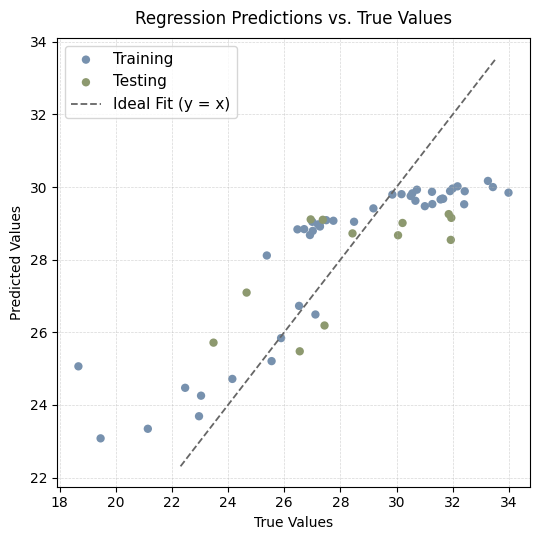

[23.482 31.856 30.212 28.43  31.948 26.942 26.552 27.372 24.66  27.434
 30.052 31.93 ]
[25.71423384 29.25370657 29.01027729 28.72272029 29.15043346 29.1082267
 25.4756216  29.09761002 27.09270467 26.18626899 28.67141516 28.54397858]


In [10]:
for element_name in ['O1s',
                    ]:
    for stage in ['P']:
        y_test, y_pred = get_feature_train(xps_df_agg, element_name = element_name, stage = stage, train_frac = 0.8, seed = 0)
        print(y_test)
        print(y_pred)


In [33]:
type(y_pred)

numpy.ndarray